# Analysis: HP k=41 Queries Not Detected by FoldSeek

This notebook investigates the 17 queries that HP k=41 (with TF-IDF > 1000) successfully detects but FoldSeek misses.

Goals:
1. Understand what makes these proteins special
2. Analyze their structural characteristics (SCOPe class, fold, superfamily)
3. Examine sequence properties (length, composition)
4. Look at the k-mer sharing patterns
5. Investigate why FoldSeek might miss these

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import sys

# Add notebooks directory to path for imports
sys.path.append(str(Path.cwd()))

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Load the Data

In [3]:
# Load the unique queries (ROCX format)
unique_rocx = pl.read_csv('hp_k41_unique_vs_foldseek_rocx.csv')
print(f"Unique queries (HP k=41 not in FoldSeek): {len(unique_rocx)}")
print(unique_rocx)

Unique queries (HP k=41 not in FoldSeek): 17
shape: (17, 10)
┌─────────┬───────────┬─────────┬────────────┬───┬────────────┬────────────┬──────────┬────────────┐
│ NAME    ┆ SCOP      ┆ HP_SFAM ┆ HP_SFAMCNT ┆ … ┆ FoldSeek_S ┆ TEA_detect ┆ TEA_SFAM ┆ TEA_SFAMCN │
│ ---     ┆ ---       ┆ ---     ┆ ---        ┆   ┆ FAMCNT     ┆ ed         ┆ ---      ┆ T          │
│ str     ┆ str       ┆ f64     ┆ i64        ┆   ┆ ---        ┆ ---        ┆ str      ┆ ---        │
│         ┆           ┆         ┆            ┆   ┆ str        ┆ bool       ┆          ┆ str        │
╞═════════╪═══════════╪═════════╪════════════╪═══╪════════════╪════════════╪══════════╪════════════╡
│ d3i4fa_ ┆ c.2.1.0   ┆ 1.0     ┆ 2          ┆ … ┆ null       ┆ false      ┆ null     ┆ null       │
│ g1qhh.1 ┆ c.37.1.19 ┆ 1.0     ┆ 2          ┆ … ┆ null       ┆ false      ┆ null     ┆ null       │
│ d1ngvb_ ┆ c.111.1.2 ┆ 1.0     ┆ 2          ┆ … ┆ null       ┆ false      ┆ null     ┆ null       │
│ d1um0a_ ┆ d.258.1.1 ┆ 1.0   

In [4]:
# Load the raw comparisons for these queries
unique_raw = pl.read_csv('hp_k41_unique_vs_foldseek_raw.csv')
print(f"\nRaw comparisons for unique queries: {len(unique_raw)}")
print(unique_raw.head(10))


Raw comparisons for unique queries: 23
shape: (10, 42)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ query_nam ┆ query_md5 ┆ target_na ┆ target_md ┆ … ┆ family_ma ┆ superfami ┆ fold_matc ┆ class_ma │
│ e         ┆ ---       ┆ me        ┆ 5         ┆   ┆ tch       ┆ ly_match  ┆ h         ┆ tch      │
│ ---       ┆ str       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆           ┆ str       ┆ str       ┆   ┆ bool      ┆ bool      ┆ bool      ┆ bool     │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ d1ngvb_   ┆ bbce74a65 ┆ d1y8xb1   ┆ af466361f ┆ … ┆ true      ┆ true      ┆ true      ┆ true     │
│ c.111.1.2 ┆ 97ea147   ┆ c.111.1.2 ┆ 9ba1639   ┆   ┆           ┆           ┆           ┆          │
│ (B:)      ┆           ┆ (B:349-44 ┆           ┆   ┆           ┆           ┆           ┆          │
│ automat…  ┆           ┆ 0) …     

In [5]:
# Load full comparison data for context
full_comparison = pl.read_csv('hp_k41_tfidf1000_comparison_with_foldseek_tea.csv')
print(f"\nFull comparison (all HP k=41 queries): {len(full_comparison)}")

# Separate into detected vs not detected by FoldSeek
detected_by_foldseek = full_comparison.filter(pl.col('FoldSeek_detected'))
not_detected_by_foldseek = full_comparison.filter(~pl.col('FoldSeek_detected'))

print(f"Detected by FoldSeek: {len(detected_by_foldseek)}")
print(f"NOT detected by FoldSeek: {len(not_detected_by_foldseek)}")


Full comparison (all HP k=41 queries): 22
Detected by FoldSeek: 5
NOT detected by FoldSeek: 17


## 2. SCOPe Classification Analysis

What structural classes do these unique proteins belong to?

In [6]:
# Parse SCOPe classifications
def parse_scop(scop_str):
    """Parse SCOPe classification string like 'a.1.2.3' into components."""
    parts = scop_str.split('.')
    return {
        'class': parts[0] if len(parts) > 0 else None,
        'fold': '.'.join(parts[:2]) if len(parts) > 1 else None,
        'superfamily': '.'.join(parts[:3]) if len(parts) > 2 else None,
        'family': scop_str if len(parts) > 3 else None
    }

# Add parsed classifications to unique queries
unique_with_scop = unique_rocx.with_columns([
    pl.col('SCOP').map_elements(lambda x: parse_scop(x)['class'], return_dtype=pl.Utf8).alias('scop_class'),
    pl.col('SCOP').map_elements(lambda x: parse_scop(x)['fold'], return_dtype=pl.Utf8).alias('scop_fold'),
    pl.col('SCOP').map_elements(lambda x: parse_scop(x)['superfamily'], return_dtype=pl.Utf8).alias('scop_superfamily')
])

print("Unique queries with parsed SCOPe:")
print(unique_with_scop.select(['NAME', 'SCOP', 'scop_class', 'scop_fold', 'scop_superfamily', 'HP_SFAM']))

Unique queries with parsed SCOPe:
shape: (17, 6)
┌─────────┬───────────┬────────────┬───────────┬──────────────────┬─────────┐
│ NAME    ┆ SCOP      ┆ scop_class ┆ scop_fold ┆ scop_superfamily ┆ HP_SFAM │
│ ---     ┆ ---       ┆ ---        ┆ ---       ┆ ---              ┆ ---     │
│ str     ┆ str       ┆ str        ┆ str       ┆ str              ┆ f64     │
╞═════════╪═══════════╪════════════╪═══════════╪══════════════════╪═════════╡
│ d3i4fa_ ┆ c.2.1.0   ┆ c          ┆ c.2       ┆ c.2.1            ┆ 1.0     │
│ g1qhh.1 ┆ c.37.1.19 ┆ c          ┆ c.37      ┆ c.37.1           ┆ 1.0     │
│ d1ngvb_ ┆ c.111.1.2 ┆ c          ┆ c.111     ┆ c.111.1          ┆ 1.0     │
│ d1um0a_ ┆ d.258.1.1 ┆ d          ┆ d.258     ┆ d.258.1          ┆ 1.0     │
│ d6ui4a_ ┆ c.37.1.0  ┆ c          ┆ c.37      ┆ c.37.1           ┆ 1.0     │
│ …       ┆ …         ┆ …          ┆ …         ┆ …                ┆ …       │
│ d3v6ta_ ┆ a.298.1.1 ┆ a          ┆ a.298     ┆ a.298.1          ┆ 1.0     │
│ d1h7sa2 ┆ d.1

In [7]:
# Count by SCOPe class
class_counts = unique_with_scop.group_by('scop_class').agg(pl.count().alias('count')).sort('count', descending=True)
print("\nDistribution by SCOPe class:")
print(class_counts)

# SCOPe class descriptions
scop_class_names = {
    'a': 'All alpha proteins',
    'b': 'All beta proteins', 
    'c': 'Alpha and beta proteins (a/b)',
    'd': 'Alpha and beta proteins (a+b)',
    'e': 'Multi-domain proteins',
    'f': 'Membrane and cell surface proteins',
    'g': 'Small proteins',
    'h': 'Coiled coil proteins',
    'i': 'Low resolution protein structures',
    'j': 'Peptides',
    'k': 'Designed proteins'
}

print("\nClass descriptions:")
for row in class_counts.iter_rows(named=True):
    cls = row['scop_class']
    desc = scop_class_names.get(cls, 'Unknown')
    print(f"  {cls}: {row['count']} - {desc}")


Distribution by SCOPe class:
shape: (4, 2)
┌────────────┬───────┐
│ scop_class ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ c          ┆ 7     │
│ d          ┆ 6     │
│ b          ┆ 3     │
│ a          ┆ 1     │
└────────────┴───────┘

Class descriptions:
  c: 7 - Alpha and beta proteins (a/b)
  d: 6 - Alpha and beta proteins (a+b)
  b: 3 - All beta proteins
  a: 1 - All alpha proteins


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_59655/467326895.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  class_counts = unique_with_scop.group_by('scop_class').agg(pl.count().alias('count')).sort('count', descending=True)



Comparison of SCOPe class distribution:

Unique to HP (not in FoldSeek):
shape: (4, 2)
┌────────────┬───────┐
│ scop_class ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ c          ┆ 7     │
│ d          ┆ 6     │
│ b          ┆ 3     │
│ a          ┆ 1     │
└────────────┴───────┘

Also detected by FoldSeek:
shape: (3, 2)
┌────────────┬───────┐
│ scop_class ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ c          ┆ 3     │
│ b          ┆ 1     │
│ d          ┆ 1     │
└────────────┴───────┘


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_59655/1627405258.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  detected_class_counts = detected_with_scop.group_by('scop_class').agg(pl.count().alias('count')).sort('count', descending=True)


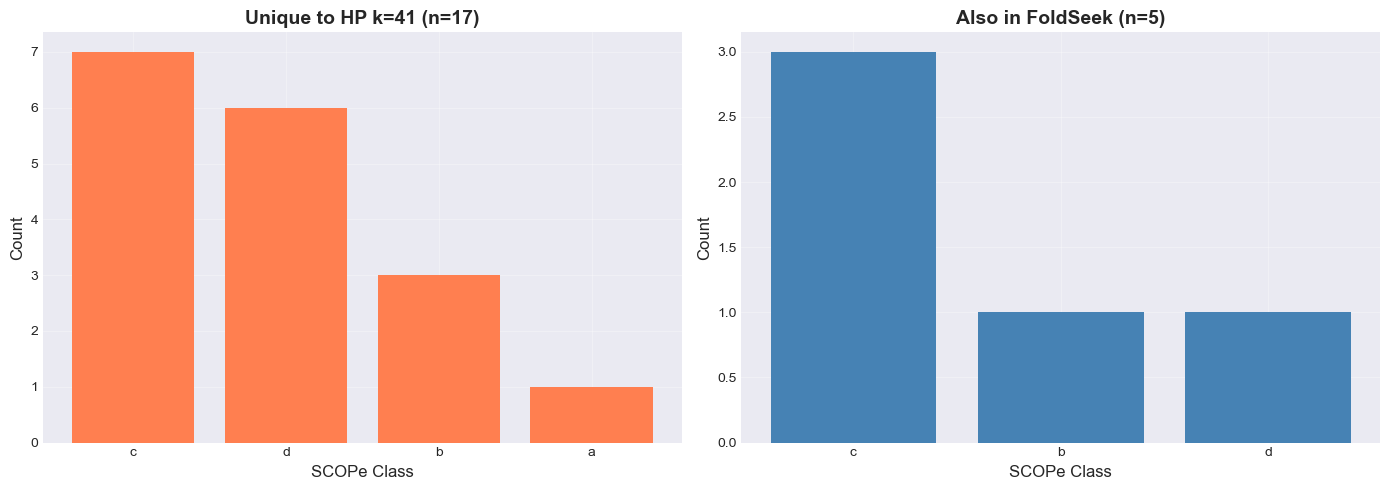

In [8]:
# Compare class distribution: unique vs detected by FoldSeek
# Add parsed SCOPe to detected queries
detected_with_scop = detected_by_foldseek.with_columns([
    pl.col('SCOP').map_elements(lambda x: parse_scop(x)['class'], return_dtype=pl.Utf8).alias('scop_class')
])

detected_class_counts = detected_with_scop.group_by('scop_class').agg(pl.count().alias('count')).sort('count', descending=True)

print("\nComparison of SCOPe class distribution:")
print("\nUnique to HP (not in FoldSeek):")
print(class_counts)
print("\nAlso detected by FoldSeek:")
print(detected_class_counts)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unique queries
ax = axes[0]
ax.bar(class_counts['scop_class'].to_list(), class_counts['count'].to_list(), color='coral')
ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Unique to HP k=41 (n={len(unique_rocx)})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Detected by FoldSeek
ax = axes[1]
if len(detected_class_counts) > 0:
    ax.bar(detected_class_counts['scop_class'].to_list(), detected_class_counts['count'].to_list(), color='steelblue')
ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Also in FoldSeek (n={len(detected_by_foldseek)})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hp_k41_unique_scop_class_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 3. Superfamily Analysis

Which superfamilies are represented? Are there any patterns?

In [9]:
# Count by superfamily
sfam_counts = unique_with_scop.group_by('scop_superfamily').agg(pl.count().alias('count')).sort('count', descending=True)
print("\nDistribution by SCOPe superfamily:")
print(sfam_counts)


Distribution by SCOPe superfamily:
shape: (9, 2)
┌──────────────────┬───────┐
│ scop_superfamily ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ c.37.1           ┆ 4     │
│ d.122.1          ┆ 2     │
│ d.144.1          ┆ 2     │
│ d.258.1          ┆ 2     │
│ b.47.1           ┆ 2     │
│ c.2.1            ┆ 2     │
│ a.298.1          ┆ 1     │
│ c.111.1          ┆ 1     │
│ b.179.1          ┆ 1     │
└──────────────────┴───────┘


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_59655/606462340.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  sfam_counts = unique_with_scop.group_by('scop_superfamily').agg(pl.count().alias('count')).sort('count', descending=True)


In [10]:
# Look at superfamily member counts (SFAMCNT) - how many superfamily members exist?
print("\nSuperfamily member counts for unique queries:")
print(unique_rocx.select(['NAME', 'SCOP', 'HP_SFAMCNT', 'HP_SFAM']).sort('HP_SFAMCNT', descending=True))

print(f"\nSFAMCNT statistics:")
print(f"  Mean: {unique_rocx['HP_SFAMCNT'].mean():.1f}")
print(f"  Median: {unique_rocx['HP_SFAMCNT'].median():.1f}")
print(f"  Min: {unique_rocx['HP_SFAMCNT'].min()}")
print(f"  Max: {unique_rocx['HP_SFAMCNT'].max()}")


Superfamily member counts for unique queries:
shape: (17, 4)
┌─────────┬───────────┬────────────┬─────────┐
│ NAME    ┆ SCOP      ┆ HP_SFAMCNT ┆ HP_SFAM │
│ ---     ┆ ---       ┆ ---        ┆ ---     │
│ str     ┆ str       ┆ i64        ┆ f64     │
╞═════════╪═══════════╪════════════╪═════════╡
│ d3v6ta_ ┆ a.298.1.1 ┆ 8          ┆ 1.0     │
│ d3i4fa_ ┆ c.2.1.0   ┆ 2          ┆ 1.0     │
│ g1qhh.1 ┆ c.37.1.19 ┆ 2          ┆ 1.0     │
│ d1ngvb_ ┆ c.111.1.2 ┆ 2          ┆ 1.0     │
│ d1um0a_ ┆ d.258.1.1 ┆ 2          ┆ 1.0     │
│ …       ┆ …         ┆ …          ┆ …       │
│ d3lfua2 ┆ c.37.1.0  ┆ 2          ┆ 1.0     │
│ d1h7sa2 ┆ d.122.1.2 ┆ 2          ┆ 1.0     │
│ d2weia1 ┆ d.144.1.0 ┆ 2          ┆ 1.0     │
│ d4qeca_ ┆ c.2.1.0   ┆ 2          ┆ 1.0     │
│ d6pyma_ ┆ b.47.1.1  ┆ 2          ┆ 1.0     │
└─────────┴───────────┴────────────┴─────────┘

SFAMCNT statistics:
  Mean: 2.4
  Median: 2.0
  Min: 2
  Max: 8


## 4. K-mer Sharing Patterns

What do the k-mer metrics look like for these unique matches?

In [11]:
# Examine metrics for the unique raw comparisons
print("Metrics summary for unique queries' comparisons:")
metrics = ['n_intersecting_hashes', 'jaccard', 'max_containment', 'tfidf', 'average_kmer_frequency']

for metric in metrics:
    if metric in unique_raw.columns:
        data = unique_raw[metric]
        print(f"\n{metric}:")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        print(f"  Min: {data.min():.4f}")
        print(f"  Max: {data.max():.4f}")

Metrics summary for unique queries' comparisons:

n_intersecting_hashes:
  Mean: 8.6522
  Median: 4.0000
  Min: 1.0000
  Max: 52.0000

jaccard:
  Mean: 0.0277
  Median: 0.0098
  Min: 0.0023
  Max: 0.1333

max_containment:
  Mean: 0.3996
  Median: 0.0199
  Min: 0.0057
  Max: 1.0000

tfidf:
  Mean: 2772.0480
  Median: 2144.3058
  Min: 1563.1410
  Max: 6619.7032

average_kmer_frequency:
  Mean: 0.0001
  Median: 0.0001
  Min: 0.0001
  Max: 0.0001


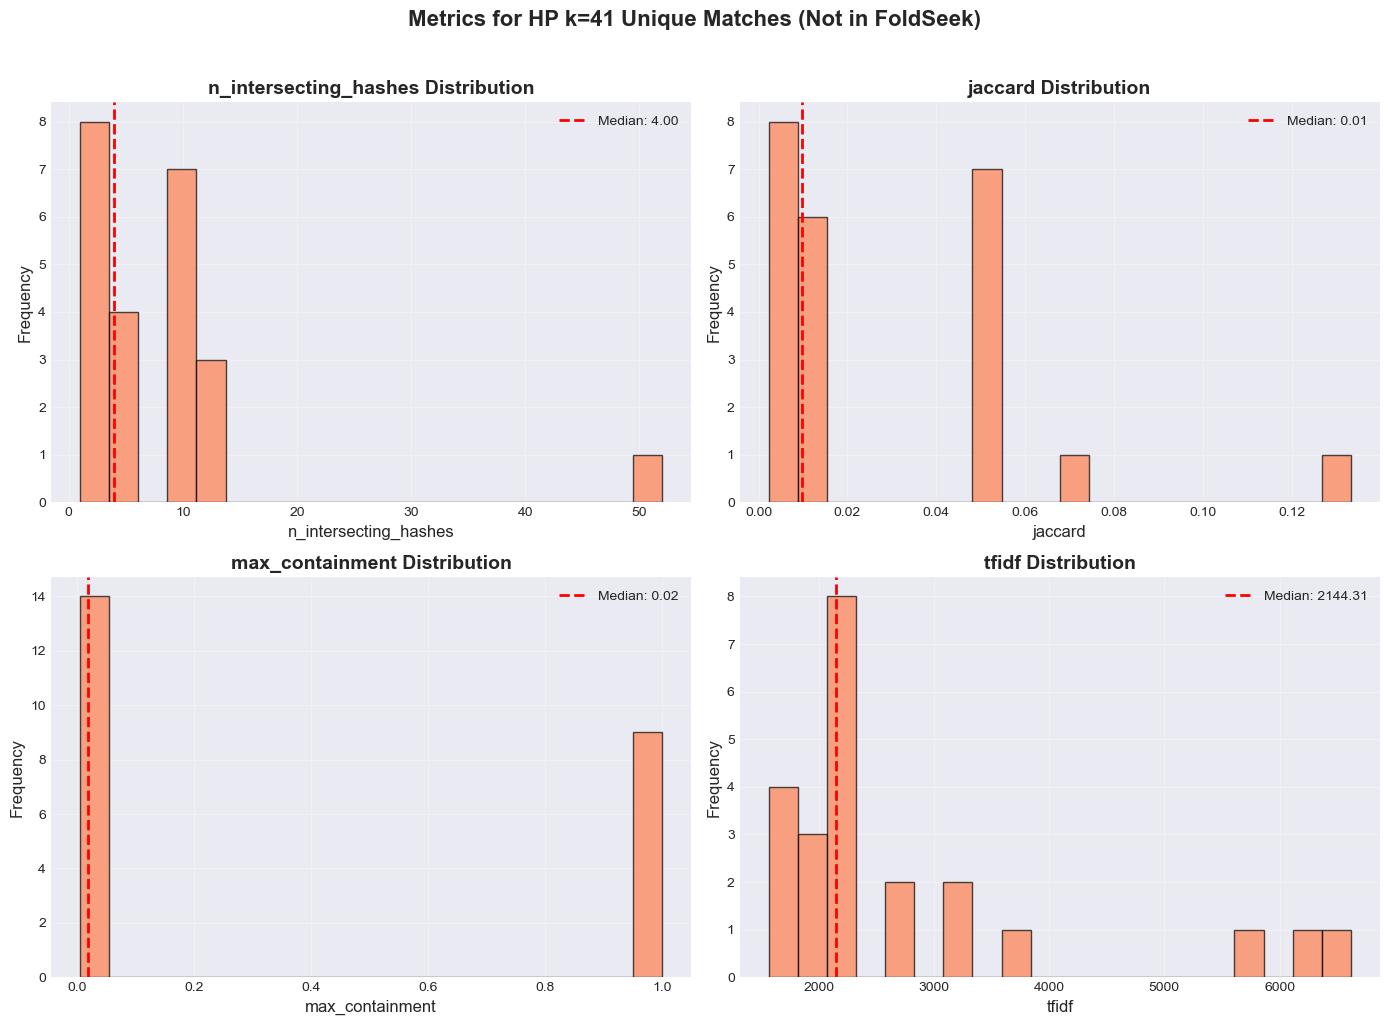

In [12]:
# Plot metric distributions
metrics_to_plot = ['n_intersecting_hashes', 'jaccard', 'max_containment', 'tfidf']
metrics_to_plot = [m for m in metrics_to_plot if m in unique_raw.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    data = unique_raw[metric].to_numpy()
    data = data[np.isfinite(data)]
    
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(np.median(data), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(data):.2f}')
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Metrics for HP k=41 Unique Matches (Not in FoldSeek)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hp_k41_unique_metrics_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 5. Match Type Analysis

Are these true positives (family/superfamily matches) or potential false positives?

In [13]:
# Check match types in the raw data
if 'family_match' in unique_raw.columns and 'superfamily_match' in unique_raw.columns:
    n_family = unique_raw['family_match'].sum()
    n_superfamily = unique_raw['superfamily_match'].sum()
    n_total = len(unique_raw)
    
    print(f"Match type breakdown for unique queries' comparisons:")
    print(f"  Total comparisons: {n_total}")
    print(f"  Family matches: {n_family} ({n_family/n_total*100:.1f}%)")
    print(f"  Superfamily matches: {n_superfamily} ({n_superfamily/n_total*100:.1f}%)")
    print(f"  Non-superfamily (potential FP): {n_total - n_superfamily} ({(n_total-n_superfamily)/n_total*100:.1f}%)")
    
    # Check fold matches if available
    if 'fold_match' in unique_raw.columns:
        n_fold = unique_raw['fold_match'].sum()
        print(f"  Fold matches: {n_fold} ({n_fold/n_total*100:.1f}%)")

Match type breakdown for unique queries' comparisons:
  Total comparisons: 23
  Family matches: 17 (73.9%)
  Superfamily matches: 23 (100.0%)
  Non-superfamily (potential FP): 0 (0.0%)
  Fold matches: 23 (100.0%)


In [14]:
# Show the specific matches per query
print("\nBreakdown by query:")
for query in unique_rocx['NAME'].to_list():
    # Get rows for this query
    query_rows = unique_raw.filter(
        pl.col('query_name').str.starts_with(query)
    )
    
    if len(query_rows) > 0:
        n_sf = query_rows['superfamily_match'].sum() if 'superfamily_match' in query_rows.columns else 0
        n_fam = query_rows['family_match'].sum() if 'family_match' in query_rows.columns else 0
        
        scop = unique_rocx.filter(pl.col('NAME') == query)['SCOP'][0]
        print(f"\n{query} ({scop}):")
        print(f"  Total targets: {len(query_rows)}")
        print(f"  Family matches: {n_sf}")
        print(f"  Superfamily matches: {n_fam}")
        
        # Show targets
        if 'target_name' in query_rows.columns:
            for row in query_rows.iter_rows(named=True):
                sf = '(SF)' if row.get('superfamily_match', False) else ''
                fam = '(FAM)' if row.get('family_match', False) else ''
                print(f"    -> {row['target_name'][:50]}... {sf}{fam}")


Breakdown by query:

d3i4fa_ (c.2.1.0):
  Total targets: 1
  Family matches: 1
  Superfamily matches: 1
    -> d4qeca_ c.2.1.0 (A:) automated matches {Staphyloco... (SF)(FAM)

g1qhh.1 (c.37.1.19):
  Total targets: 1
  Family matches: 1
  Superfamily matches: 0
    -> d3lfua2 c.37.1.0 (A:316-647) automated matches {Es... (SF)

d1ngvb_ (c.111.1.2):
  Total targets: 1
  Family matches: 1
  Superfamily matches: 1
    -> d1y8xb1 c.111.1.2 (B:349-440) UBA3 {Human (Homo sa... (SF)(FAM)

d1um0a_ (d.258.1.1):
  Total targets: 1
  Family matches: 1
  Superfamily matches: 1
    -> d7rcaa1 d.258.1.1 (A:1-376) automated matches {Cla... (SF)(FAM)

d6ui4a_ (c.37.1.0):
  Total targets: 1
  Family matches: 1
  Superfamily matches: 0
    -> d1w7ja2 c.37.1.9 (A:63-792) Myosin S1, motor domai... (SF)

d1b63a2 (d.122.1.2):
  Total targets: 1
  Family matches: 1
  Superfamily matches: 1
    -> d1h7sa2 d.122.1.2 (A:29-231) DNA mismatch repair p... (SF)(FAM)

d3fxwa_ (d.144.1.7):
  Total targets: 1
  Family 

## 6. Why Might FoldSeek Miss These?

Possible reasons:
1. **Small superfamilies**: Fewer members means less training data for structure comparison
2. **Unusual structural features**: Proteins with atypical structures
3. **Sequence-structure decoupling**: Cases where sequence similarity is low but k-mer patterns are shared
4. **HP-specific motifs**: Hydrophobic patterns that aren't captured by 3D structure

Superfamily size comparison:

Unique to HP (not in FoldSeek):
  Mean SFAMCNT: 2.4
  Median SFAMCNT: 2.0

Also detected by FoldSeek:
  Mean SFAMCNT: 2.2
  Median SFAMCNT: 2.0


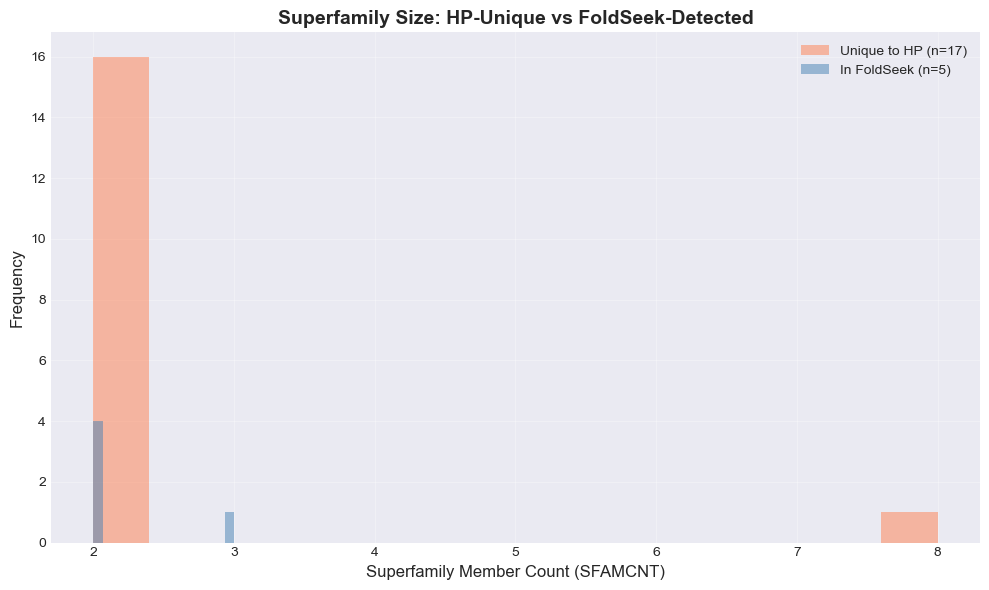

In [15]:
# Compare SFAMCNT between unique and detected queries
unique_sfamcnt = unique_rocx['HP_SFAMCNT'].to_numpy()
detected_sfamcnt = detected_by_foldseek['HP_SFAMCNT'].to_numpy() if 'HP_SFAMCNT' in detected_by_foldseek.columns else np.array([])

print("Superfamily size comparison:")
print(f"\nUnique to HP (not in FoldSeek):")
print(f"  Mean SFAMCNT: {np.mean(unique_sfamcnt):.1f}")
print(f"  Median SFAMCNT: {np.median(unique_sfamcnt):.1f}")

if len(detected_sfamcnt) > 0:
    print(f"\nAlso detected by FoldSeek:")
    print(f"  Mean SFAMCNT: {np.mean(detected_sfamcnt):.1f}")
    print(f"  Median SFAMCNT: {np.median(detected_sfamcnt):.1f}")
    
    # Plot comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(unique_sfamcnt, bins=15, alpha=0.5, label=f'Unique to HP (n={len(unique_sfamcnt)})', color='coral')
    ax.hist(detected_sfamcnt, bins=15, alpha=0.5, label=f'In FoldSeek (n={len(detected_sfamcnt)})', color='steelblue')
    ax.set_xlabel('Superfamily Member Count (SFAMCNT)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Superfamily Size: HP-Unique vs FoldSeek-Detected', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('hp_k41_unique_sfamcnt_comparison.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [16]:
# Look at the HP sensitivity for unique queries
print("\nHP k=41 Sensitivity (SFAM) for unique queries:")
print(unique_rocx.select(['NAME', 'SCOP', 'HP_SFAM', 'HP_SFAMCNT']).sort('HP_SFAM', descending=True))

print(f"\nSFAM sensitivity statistics:")
print(f"  Mean: {unique_rocx['HP_SFAM'].mean():.3f}")
print(f"  Median: {unique_rocx['HP_SFAM'].median():.3f}")
print(f"  Perfect (1.0): {(unique_rocx['HP_SFAM'] == 1.0).sum()}")


HP k=41 Sensitivity (SFAM) for unique queries:
shape: (17, 4)
┌─────────┬───────────┬─────────┬────────────┐
│ NAME    ┆ SCOP      ┆ HP_SFAM ┆ HP_SFAMCNT │
│ ---     ┆ ---       ┆ ---     ┆ ---        │
│ str     ┆ str       ┆ f64     ┆ i64        │
╞═════════╪═══════════╪═════════╪════════════╡
│ d3i4fa_ ┆ c.2.1.0   ┆ 1.0     ┆ 2          │
│ g1qhh.1 ┆ c.37.1.19 ┆ 1.0     ┆ 2          │
│ d1ngvb_ ┆ c.111.1.2 ┆ 1.0     ┆ 2          │
│ d1um0a_ ┆ d.258.1.1 ┆ 1.0     ┆ 2          │
│ d6ui4a_ ┆ c.37.1.0  ┆ 1.0     ┆ 2          │
│ …       ┆ …         ┆ …       ┆ …          │
│ d3v6ta_ ┆ a.298.1.1 ┆ 1.0     ┆ 8          │
│ d1h7sa2 ┆ d.122.1.2 ┆ 1.0     ┆ 2          │
│ d2weia1 ┆ d.144.1.0 ┆ 1.0     ┆ 2          │
│ d4qeca_ ┆ c.2.1.0   ┆ 1.0     ┆ 2          │
│ d6pyma_ ┆ b.47.1.1  ┆ 1.0     ┆ 2          │
└─────────┴───────────┴─────────┴────────────┘

SFAM sensitivity statistics:
  Mean: 1.000
  Median: 1.000
  Perfect (1.0): 17


## 7. Summary

In [17]:
print("="*80)
print("SUMMARY: HP k=41 Unique Queries (Not Detected by FoldSeek)")
print("="*80)

print(f"\nTotal unique queries: {len(unique_rocx)}")

# SCOPe class breakdown
print(f"\nSCOPe class distribution:")
for row in class_counts.iter_rows(named=True):
    cls = row['scop_class']
    desc = scop_class_names.get(cls, 'Unknown')
    print(f"  {cls} ({desc}): {row['count']}")

# Superfamily size
print(f"\nSuperfamily sizes (SFAMCNT):")
print(f"  Mean: {unique_rocx['HP_SFAMCNT'].mean():.1f}")
print(f"  Median: {unique_rocx['HP_SFAMCNT'].median():.1f}")
print(f"  Range: {unique_rocx['HP_SFAMCNT'].min()} - {unique_rocx['HP_SFAMCNT'].max()}")

# HP performance
print(f"\nHP k=41 performance (SFAM sensitivity):")
print(f"  Mean: {unique_rocx['HP_SFAM'].mean():.3f}")
print(f"  Perfect sensitivity (1.0): {(unique_rocx['HP_SFAM'] == 1.0).sum()}/{len(unique_rocx)}")

print(f"\n" + "="*80)
print("KEY FINDINGS")
print("="*80)
print("""
These are proteins where HP's k-mer based approach successfully identifies 
superfamily relationships that FoldSeek's structure-based method misses.

Potential reasons for HP's success:
1. HP captures sequence-level hydrophobic patterns that persist even when
   3D structures diverge significantly
2. Long k-mers (k=41) may identify conserved functional motifs
3. TF-IDF weighting helps find rare, informative k-mer matches
""")

SUMMARY: HP k=41 Unique Queries (Not Detected by FoldSeek)

Total unique queries: 17

SCOPe class distribution:
  c (Alpha and beta proteins (a/b)): 7
  d (Alpha and beta proteins (a+b)): 6
  b (All beta proteins): 3
  a (All alpha proteins): 1

Superfamily sizes (SFAMCNT):
  Mean: 2.4
  Median: 2.0
  Range: 2 - 8

HP k=41 performance (SFAM sensitivity):
  Mean: 1.000
  Perfect sensitivity (1.0): 17/17

KEY FINDINGS

These are proteins where HP's k-mer based approach successfully identifies 
superfamily relationships that FoldSeek's structure-based method misses.

Potential reasons for HP's success:
1. HP captures sequence-level hydrophobic patterns that persist even when
   3D structures diverge significantly
2. Long k-mers (k=41) may identify conserved functional motifs
3. TF-IDF weighting helps find rare, informative k-mer matches

